# ChromBPNet: Predictions & Attributions via bpnet-lite

Load pretrained ChromBPNet models (TF h5 -> PyTorch), make variant effect predictions, and compute DeepLIFT/SHAP attributions.

**Env**: `chrombpnet_torch` kernel (bpnet-lite + tangermeme + PyTorch)

## 0. Setup & Imports

In [1]:
import torch
import numpy as np
import pandas as pd
import tarfile
from io import BytesIO
from pathlib import Path

from bpnetlite import BPNet
from bpnetlite.chrombpnet import ChromBPNet
from bpnetlite.bpnet import CountWrapper

from tangermeme.predict import predict
from tangermeme.deep_lift_shap import deep_lift_shap

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA H100 NVL


## 1. Paths & Model Config

Using the **GM12878 (LCL) DNase-seq** ChromBPNet model from ENCODE.
- File: `ENCFF673TIN` (experiment ENCSR003WJE)
- Contains 5 cross-validation folds, each with bias + accessibility h5 files
- We only need the **accessibility model** (`chrombpnet_nobias`) for VEP and attributions

**Reference genome**: `GRCh38.p13.genome.fa` from AlphaGenome's GCS bucket — matches the assembly used to generate AlphaGenome variant predictions. ChromBPNet was trained on GRCh38 no-alt analysis set (compatible for main chromosomes).

In [2]:
BASE_DIR = Path("/grid/wsbs/home_norepl/pmantill/Human_nc_variants/SEAM_population_analysis")
MODEL_DIR = BASE_DIR / "SEAM_ChromBPNet" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# GM12878 (LCL) DNase-seq ChromBPNet model
MODEL_TARBALL = MODEL_DIR / "ENCFF673TIN.tar.gz"

# Download if not present
if not MODEL_TARBALL.exists():
    print("Downloading GM12878 DNase-seq ChromBPNet model from ENCODE...")
    import subprocess
    subprocess.run([
        "wget", "-q", "--show-progress",
        "https://www.encodeproject.org/files/ENCFF673TIN/@@download/ENCFF673TIN.tar.gz",
        "-O", str(MODEL_TARBALL)
    ], check=True)
    print(f"Downloaded to {MODEL_TARBALL} ({MODEL_TARBALL.stat().st_size / 1e6:.0f} MB)")
else:
    print(f"Model already exists: {MODEL_TARBALL} ({MODEL_TARBALL.stat().st_size / 1e6:.0f} MB)")

# Reference genome — GRCh38.p13 (same assembly used by AlphaGenome)
# ChromBPNet uses GRCh38 no-alt analysis set; both are compatible for main chromosomes
GENOME_FA = str(BASE_DIR / "variant_data" / "hg38_reference" / "GRCh38.p13.genome.fa")

# Variant data (caQTL from AlphaGenome)
VARIANT_DIR = BASE_DIR / "variant_data" / "Alphagenome_data" / "chromatin_accessibility_qtl"

Model already exists: /grid/wsbs/home_norepl/pmantill/Human_nc_variants/SEAM_population_analysis/SEAM_ChromBPNet/models/ENCFF673TIN.tar.gz (725 MB)


## 2. Load Accessibility Model from ENCODE tar.gz

We load only the **accessibility model** (`chrombpnet_nobias`). This is the de-biased BPNet that learned true chromatin accessibility signal — the bias model was used during training to factor out enzyme preferences and can be discarded for inference.

In [3]:
# List contents of the tarball to find model files
with tarfile.open(MODEL_TARBALL, "r:gz") as tar:
    h5_files = [n for n in tar.getnames() if n.endswith(".h5")]
    print("H5 files in tarball:")
    for f in sorted(h5_files):
        print(f"  {f}")

# Load the accessibility model (fold 0) directly as a BPNet
FOLD = 0

with tarfile.open(MODEL_TARBALL, "r:gz") as tar:
    names = tar.getnames()
    acc_file = [n for n in names if f"fold_{FOLD}" in n and "chrombpnet_nobias" in n and n.endswith(".h5")]
    assert len(acc_file) == 1, f"Expected 1 accessibility model for fold {FOLD}, found: {acc_file}"
    
    print(f"\nLoading accessibility model: {acc_file[0]}")
    acc_data = tar.extractfile(acc_file[0]).read()

acc_model = BPNet.from_chrombpnet(BytesIO(acc_data))
acc_model = acc_model.to(device).eval()

print(f"\nModel loaded successfully!")
print(f"Parameters: {sum(p.numel() for p in acc_model.parameters()):,}")
print(acc_model)

H5 files in tarball:
  ./fold_0/model.bias_scaled.fold_0.ENCSR000EMT.h5
  ./fold_0/model.chrombpnet.fold_0.ENCSR000EMT.h5
  ./fold_0/model.chrombpnet_nobias.fold_0.ENCSR000EMT.h5
  ./fold_1/model.bias_scaled.fold_1.ENCSR000EMT.h5
  ./fold_1/model.chrombpnet.fold_1.ENCSR000EMT.h5
  ./fold_1/model.chrombpnet_nobias.fold_1.ENCSR000EMT.h5
  ./fold_2/model.bias_scaled.fold_2.ENCSR000EMT.h5
  ./fold_2/model.chrombpnet.fold_2.ENCSR000EMT.h5
  ./fold_2/model.chrombpnet_nobias.fold_2.ENCSR000EMT.h5
  ./fold_3/model.bias_scaled.fold_3.ENCSR000EMT.h5
  ./fold_3/model.chrombpnet.fold_3.ENCSR000EMT.h5
  ./fold_3/model.chrombpnet_nobias.fold_3.ENCSR000EMT.h5
  ./fold_4/model.bias_scaled.fold_4.ENCSR000EMT.h5
  ./fold_4/model.chrombpnet.fold_4.ENCSR000EMT.h5
  ./fold_4/model.chrombpnet_nobias.fold_4.ENCSR000EMT.h5

Loading accessibility model: ./fold_0/model.chrombpnet_nobias.fold_0.ENCSR000EMT.h5

Model loaded successfully!
Parameters: 6,377,986
BPNet(
  (iconv): Conv1d(4, 512, kernel_size=(21,), st

## 3. Sequence Encoding Utilities

In [4]:
from pyfaidx import Fasta

# One-hot encoding: A=0, C=1, G=2, T=3
ENCODE_MAP = {'A': 0, 'C': 1, 'G': 2, 'T': 3,
              'a': 0, 'c': 1, 'g': 2, 't': 3}

def one_hot_encode(seq):
    """Convert DNA string to one-hot tensor (4, len)."""
    arr = np.zeros((4, len(seq)), dtype=np.float32)
    for i, base in enumerate(seq):
        if base in ENCODE_MAP:
            arr[ENCODE_MAP[base], i] = 1.0
    return arr


def extract_sequence(genome, chrom, center_0based, window=2114):
    """Extract a sequence centered on `center_0based` from the genome (0-based)."""
    half = window // 2
    start = center_0based - half
    end = start + window
    seq = str(genome[chrom][start:end])
    return seq


def parse_variant_id(variant_id):
    """Parse variant_id like 'chr12_103626683_T_C_hg38' -> (chrom, pos_1based, allele1, allele2).
    
    NOTE: allele1/allele2 are NOT necessarily REF/ALT in VCF convention.
    AlphaGenome uses effect/other allele encoding — ~18% of variants have
    allele1 matching ALT (not REF) in the genome. Use the genome to determine
    the true REF allele.
    """
    parts = variant_id.split('_')
    chrom = parts[0]
    pos = int(parts[1])
    allele1 = parts[2]
    allele2 = parts[3]
    return chrom, pos, allele1, allele2


def make_ref_alt_seqs(genome, chrom, pos_1based, allele1, allele2, window=2114):
    """Create ref and alt one-hot encoded sequences centered on variant.
    
    pos_1based: 1-based coordinate from variant ID (VCF convention).
    allele1/allele2: from variant ID — may be swapped vs genome REF.
    We use the genome to determine true REF, and the other allele becomes ALT.
    
    Returns: (ref_ohe, alt_ohe, was_swapped)
    """
    pos_0based = pos_1based - 1  # Convert 1-based -> 0-based for pyfaidx
    seq = extract_sequence(genome, chrom, pos_0based, window)
    center_idx = window // 2
    
    genome_base = seq[center_idx].upper()
    
    # Determine true REF/ALT based on genome
    if genome_base == allele1.upper():
        ref, alt = allele1, allele2
        swapped = False
    elif genome_base == allele2.upper():
        ref, alt = allele2, allele1
        swapped = True
    else:
        # Neither allele matches genome — skip this variant
        raise ValueError(
            f"Neither allele matches genome at {chrom}:{pos_1based}: "
            f"genome={genome_base}, alleles={allele1}/{allele2}"
        )
    
    # Create alt sequence (SNV only)
    seq_list = list(seq)
    alt_seq_list = list(seq)
    alt_seq_list[center_idx] = alt
    
    ref_ohe = one_hot_encode(''.join(seq_list))
    alt_ohe = one_hot_encode(''.join(alt_seq_list))
    
    return ref_ohe, alt_ohe, swapped


print("Sequence utilities loaded.")

Sequence utilities loaded.


## 4. Predictions: Variant Effect Scores

For each variant, predict chromatin accessibility for ref and alt alleles, then compute the difference (log fold change in counts, profile difference).

In [5]:
# Load reference genome
genome = Fasta(GENOME_FA)
print(f"Loaded genome with {len(genome.keys())} chromosomes")

Loaded genome with 639 chromosomes


In [6]:
# ---- Choose population / dataset ----
# Options: "caqtl_african", "caqtl_european", "dsqtl_yoruba"
POPULATION = "caqtl_european"

# Map population to output folder name
POP_FOLDER_MAP = {
    "caqtl_african": "African",
    "caqtl_european": "European",
    "dsqtl_yoruba": "Yoruba",
}
POP_FOLDER = POP_FOLDER_MAP[POPULATION]

# Output directory for figures
FIG_DIR = BASE_DIR / "SEAM_ChromBPNet" / "test_ChromBPNET" / "prelim_population_analysis" / POP_FOLDER
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR}")

# Load causality file (binary target: causal=1, non-causal=0, all variants)
causality_file = VARIANT_DIR / f"{POPULATION}_variant_causality_human_predictions.feather"
df_causality = pd.read_feather(causality_file)
print(f"\nCausality: {causality_file.name}  —  {len(df_causality)} variants")
print(f"  Causal: {(df_causality['target']==1).sum()}, Non-causal: {(df_causality['target']==0).sum()}")

# Load coefficient file (continuous target = measured effect size, causal variants only)
coeff_file = VARIANT_DIR / f"{POPULATION}_variant_coefficient_human_predictions.feather"
df_coefficient = pd.read_feather(coeff_file)
print(f"\nCoefficient: {coeff_file.name}  —  {len(df_coefficient)} variants")
print(f"  Target range: [{df_coefficient['target'].min():.3f}, {df_coefficient['target'].max():.3f}]")
print(f"  AlphaGenome prediction range: [{df_coefficient['prediction'].min():.3f}, {df_coefficient['prediction'].max():.3f}]")

Figures will be saved to: /grid/wsbs/home_norepl/pmantill/Human_nc_variants/SEAM_population_analysis/SEAM_ChromBPNet/test_ChromBPNET/prelim_population_analysis/European

Causality: caqtl_european_variant_causality_human_predictions.feather  —  31621 variants
  Causal: 2618, Non-causal: 29003

Coefficient: caqtl_european_variant_coefficient_human_predictions.feather  —  2618 variants
  Target range: [-2.017, 2.326]
  AlphaGenome prediction range: [-3.427, 4.186]


In [7]:
def predict_variant_effects(model, genome, variant_ids, device='cuda', batch_size=32):
    """Compute variant effect predictions for a list of variant IDs.
    
    Returns DataFrame with:
        - ref_logcounts, alt_logcounts: predicted log counts
        - log2fc: log2 fold change (alt/ref)
        - allele_swapped: True if variant ID alleles were swapped vs genome REF
    """
    ref_seqs, alt_seqs, valid_ids, swap_flags = [], [], [], []
    for vid in variant_ids:
        try:
            chrom, pos, allele1, allele2 = parse_variant_id(vid)
            ref_ohe, alt_ohe, swapped = make_ref_alt_seqs(genome, chrom, pos, allele1, allele2)
            ref_seqs.append(ref_ohe)
            alt_seqs.append(alt_ohe)
            valid_ids.append(vid)
            swap_flags.append(swapped)
        except Exception as e:
            print(f"Skipping {vid}: {e}")
    
    if not ref_seqs:
        return pd.DataFrame()
    
    # Stack into tensors
    X_ref = torch.tensor(np.stack(ref_seqs), dtype=torch.float32)
    X_alt = torch.tensor(np.stack(alt_seqs), dtype=torch.float32)
    
    # Predict in batches using tangermeme
    model.eval()
    with torch.no_grad():
        ref_profile, ref_counts = predict(model, X_ref, batch_size=batch_size, device=device)
        alt_profile, alt_counts = predict(model, X_alt, batch_size=batch_size, device=device)
    
    # Compute variant effect scores
    ref_lc = ref_counts.squeeze().numpy()
    alt_lc = alt_counts.squeeze().numpy()
    log2fc = (alt_lc - ref_lc) / np.log(2)  # Convert from natural log to log2
    
    return pd.DataFrame({
        'variant_id': valid_ids,
        'ref_logcounts': ref_lc,
        'alt_logcounts': alt_lc,
        'log2fc': log2fc,
        'allele_swapped': swap_flags
    })


# Run on a small test set first
test_variants = df_coefficient['variant_id'].unique()[:10]
print(f"Testing with {len(test_variants)} variants...")

vep_results = predict_variant_effects(acc_model, genome, test_variants, device=device)
print(f"Swapped alleles: {vep_results['allele_swapped'].sum()} / {len(vep_results)}")
vep_results

Testing with 10 variants...
Swapped alleles: 0 / 10


,variant_id,ref_logcounts,alt_logcounts,log2fc,allele_swapped
0,chr12_189334_G_A_hg38,4.637460,4.553973,-0.120447,False
1,chr12_454142_C_T_hg38,4.465742,4.385451,-0.115835,False
2,chr12_553672_T_C_hg38,4.303654,4.967816,0.958183,False
3,chr12_630843_C_G_hg38,5.779337,5.236663,-0.782912,False
4,chr12_722717_C_T_hg38,3.625441,3.620693,-0.006849,False
5,chr12_3742080_G_A_hg38,3.610752,3.473900,-0.197436,False
6,chr12_3742130_A_G_hg38,3.633522,3.580554,-0.076416,False
7,chr12_3744030_T_A_hg38,3.866286,4.174483,0.444635,False
8,chr12_3827775_T_G_hg38,4.360465,4.726695,0.528358,False
9,chr12_5040593_G_A_hg38,4.116355,4.374460,0.372367,False


## 5. Attributions: DeepLIFT/SHAP

Compute contribution scores for each nucleotide position. Uses dinucleotide-shuffled backgrounds.

In [8]:
def compute_attributions(model, sequences, n_shuffles=50, batch_size=8, device='cuda'):
    """Compute DeepLIFT/SHAP attributions for one-hot encoded sequences.
    
    Args:
        model: BPNet accessibility model
        sequences: np.array of shape (n, 4, 2114) — one-hot encoded
        n_shuffles: number of dinucleotide shuffle references
        batch_size: batch size for attribution computation
    
    Returns:
        np.array of shape (n, 4, 2114) — attribution scores (hypothetical)
    """
    X = torch.tensor(sequences, dtype=torch.float32)
    
    # Use CountWrapper to attribute to the count output (scalar)
    count_model = CountWrapper(model).to(device)
    
    attrs = deep_lift_shap(
        count_model,
        X,
        n_shuffles=n_shuffles,
        batch_size=batch_size,
        device=device,
        hypothetical=True  # Get scores for all possible bases, not just observed
    )
    
    return attrs.numpy()


# Pick a variant with a large effect for a more interesting attribution map
top_variant_idx = vep_results['log2fc'].abs().idxmax()
test_vid = vep_results.loc[top_variant_idx, 'variant_id']
chrom, pos, allele1, allele2 = parse_variant_id(test_vid)
ref_ohe, alt_ohe, swapped = make_ref_alt_seqs(genome, chrom, pos, allele1, allele2)

print(f"Computing attributions for {test_vid}...")
print(f"  Alleles swapped vs genome: {swapped}")
print(f"  log2FC: {vep_results.loc[top_variant_idx, 'log2fc']:.4f}")
ref_attr = compute_attributions(acc_model, ref_ohe[np.newaxis], device=device)
alt_attr = compute_attributions(acc_model, alt_ohe[np.newaxis], device=device)

print(f"Attribution shape: {ref_attr.shape}")
print(f"Max attribution (ref): {np.abs(ref_attr).max():.4f}")
print(f"Max attribution (alt): {np.abs(alt_attr).max():.4f}")

Computing attributions for chr12_553672_T_C_hg38...
  Alleles swapped vs genome: False
  log2FC: 0.9582
Attribution shape: (1, 4, 2114)
Max attribution (ref): 0.0738
Max attribution (alt): 0.0717


## 6. Visualization

Saved: /grid/wsbs/home_norepl/pmantill/Human_nc_variants/SEAM_population_analysis/SEAM_ChromBPNet/test_ChromBPNET/prelim_population_analysis/European/attribution_logos_chr12_553672_T_C_hg38.png


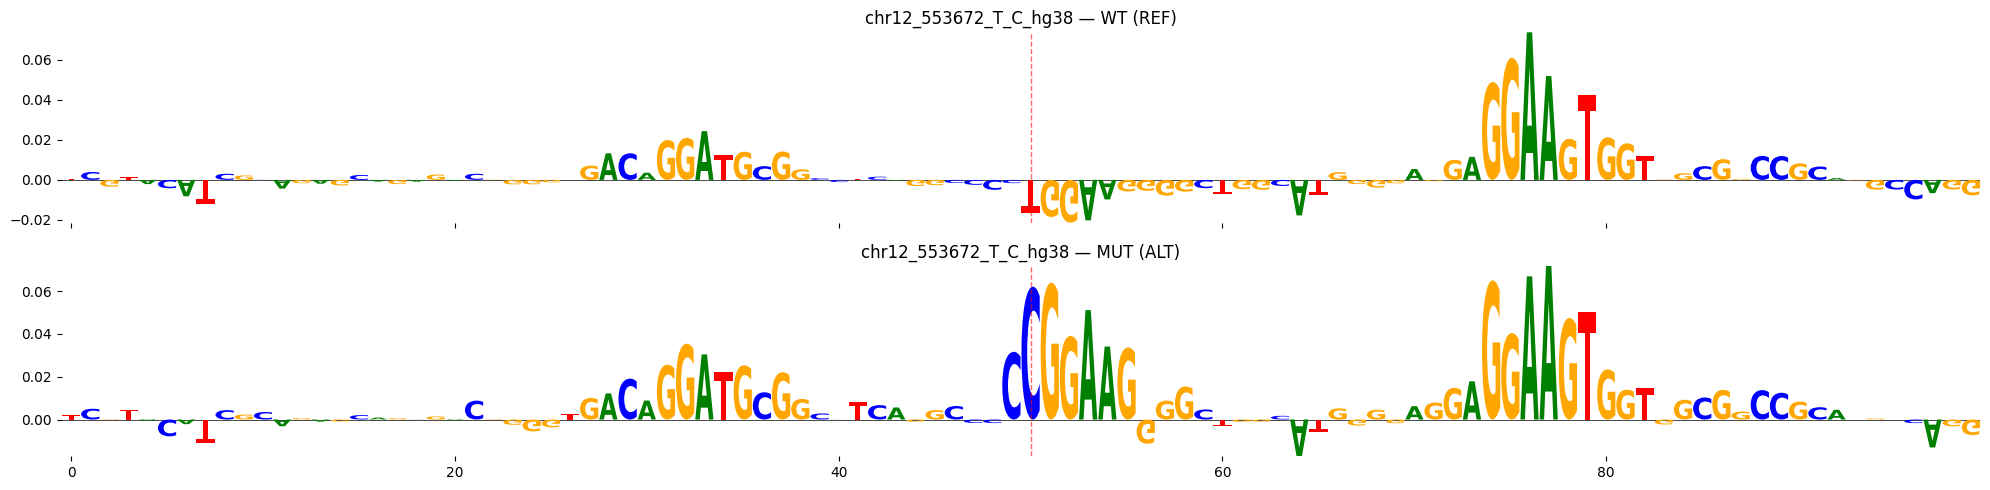

In [9]:
import matplotlib.pyplot as plt
from tangermeme.plot import plot_logo

def plot_variant_logos(ref_attr, alt_attr, ref_ohe, alt_ohe, variant_id,
                       center_idx=1057, window=50, save_path=None):
    """Plot REF and ALT attribution logos around the variant position.
    
    Passes projected attributions (attr * one-hot) so logos show actual base contributions.
    """
    start = center_idx - window
    end = center_idx + window
    
    # Projected attributions: contribution of actual bases
    ref_proj = torch.tensor(ref_attr * ref_ohe)[:, start:end]
    alt_proj = torch.tensor(alt_attr * alt_ohe)[:, start:end]
    
    # Shared y-axis limits
    ymax = max(ref_proj.abs().sum(0).max().item(), alt_proj.abs().sum(0).max().item())
    ylim = (-ymax * 1.1, ymax * 1.1)
    
    fig, axes = plt.subplots(2, 1, figsize=(20, 5), sharex=True)
    
    plot_logo(ref_proj, ax=axes[0], ylim=ylim)
    axes[0].set_title(f"{variant_id} — WT (REF)")
    axes[0].axvline(window, color='red', linestyle='--', alpha=0.6, linewidth=1)
    
    plot_logo(alt_proj, ax=axes[1], ylim=ylim)
    axes[1].set_title(f"{variant_id} — MUT (ALT)")
    axes[1].axvline(window, color='red', linestyle='--', alpha=0.6, linewidth=1)
    
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


# Plot and save ref vs alt attribution logos
attr_fig_path = FIG_DIR / f"attribution_logos_{test_vid.replace(':', '_')}.png"
plot_variant_logos(ref_attr[0], alt_attr[0], ref_ohe, alt_ohe, test_vid,
                   save_path=attr_fig_path)

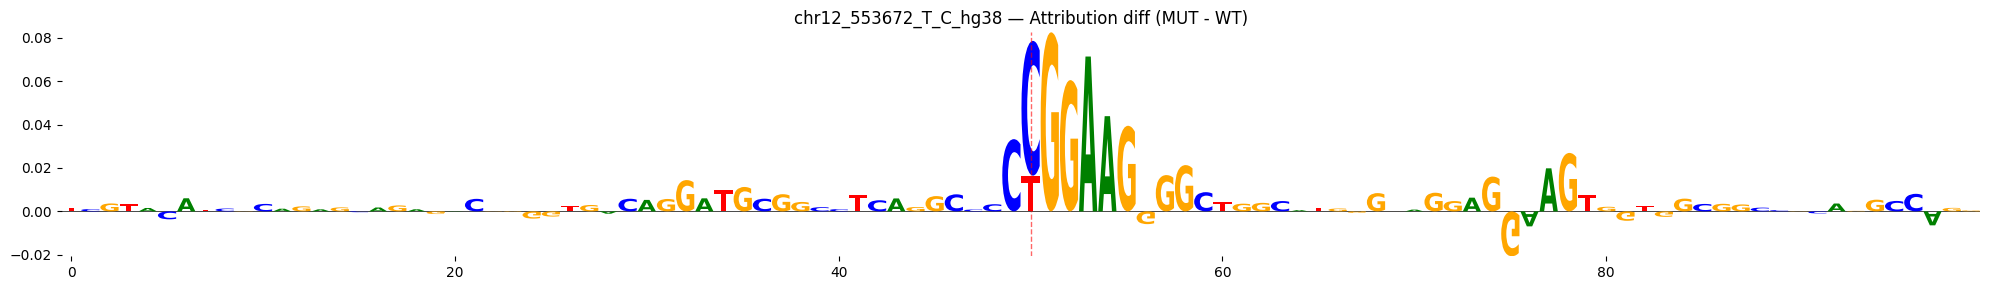

In [10]:
def plot_attribution_diff_logo(ref_attr, alt_attr, ref_ohe, alt_ohe, variant_id,
                               center_idx=1057, window=50):
    """Plot difference in attribution (ALT - REF) as a logo."""
    start = center_idx - window
    end = center_idx + window
    
    # Difference in projected attributions
    ref_proj = ref_attr * ref_ohe
    alt_proj = alt_attr * alt_ohe
    diff = torch.tensor(alt_proj - ref_proj)[:, start:end]
    
    fig, ax = plt.subplots(figsize=(20, 3))
    plot_logo(diff, ax=ax)
    ax.set_title(f"{variant_id} — Attribution diff (MUT - WT)")
    ax.axvline(window, color='red', linestyle='--', alpha=0.6, linewidth=1)
    plt.tight_layout()
    plt.show()


plot_attribution_diff_logo(ref_attr[0], alt_attr[0], ref_ohe, alt_ohe, test_vid)

## 7. Batch Processing: All Variants

In [11]:
# Run ChromBPNet VEP on ALL causality variants (for binary classification plot)
all_causality_variants = df_causality['variant_id'].unique()
print(f"Running VEP on {len(all_causality_variants)} causality variants...")
vep_causality = predict_variant_effects(acc_model, genome, all_causality_variants, device=device, batch_size=64)
merged_causality = df_causality.merge(vep_causality, on='variant_id', how='inner')
print(f"Merged causality: {merged_causality.shape}")

# Run ChromBPNet VEP on coefficient variants (for correlation plot)
# These are a subset of causality target=1, so reuse predictions where possible
coeff_variants = df_coefficient['variant_id'].unique()
vep_coeff = vep_causality[vep_causality['variant_id'].isin(coeff_variants)]
merged_coefficient = df_coefficient.merge(vep_coeff, on='variant_id', how='inner')
print(f"Merged coefficient: {merged_coefficient.shape}")
merged_coefficient.head()

Running VEP on 31621 causality variants...
Merged causality: (31621, 11)
Merged coefficient: (2618, 11)


,variant_id,prediction,target,variant_scorer,output_type,metric_calculator,metric_name,ref_logcounts,alt_logcounts,log2fc,allele_swapped
0,chr12_189334_G_A_hg38,-0.082306,0.737333,center_mask_diff_log2_sum;width=501;mask_decay...,DNASE,SimpleAggregatorCorrelationCalculator,pearsonr_mean_track_aggregation_ontology_curie...,4.637460,4.553973,-0.120447,False
1,chr12_454142_C_T_hg38,-0.120501,-1.138070,center_mask_diff_log2_sum;width=501;mask_decay...,DNASE,SimpleAggregatorCorrelationCalculator,pearsonr_mean_track_aggregation_ontology_curie...,4.465742,4.385451,-0.115835,False
2,chr12_553672_T_C_hg38,1.842070,1.218160,center_mask_diff_log2_sum;width=501;mask_decay...,DNASE,SimpleAggregatorCorrelationCalculator,pearsonr_mean_track_aggregation_ontology_curie...,4.303654,4.967816,0.958183,False
3,chr12_630843_C_G_hg38,-1.527382,-1.080100,center_mask_diff_log2_sum;width=501;mask_decay...,DNASE,SimpleAggregatorCorrelationCalculator,pearsonr_mean_track_aggregation_ontology_curie...,5.779337,5.236663,-0.782912,False
4,chr12_722717_C_T_hg38,0.024603,0.782187,center_mask_diff_log2_sum;width=501;mask_decay...,DNASE,SimpleAggregatorCorrelationCalculator,pearsonr_mean_track_aggregation_ontology_curie...,3.625441,3.620693,-0.006849,False


Saved: /grid/wsbs/home_norepl/pmantill/Human_nc_variants/SEAM_population_analysis/SEAM_ChromBPNet/test_ChromBPNET/prelim_population_analysis/European/causality_coefficient_comparison.png


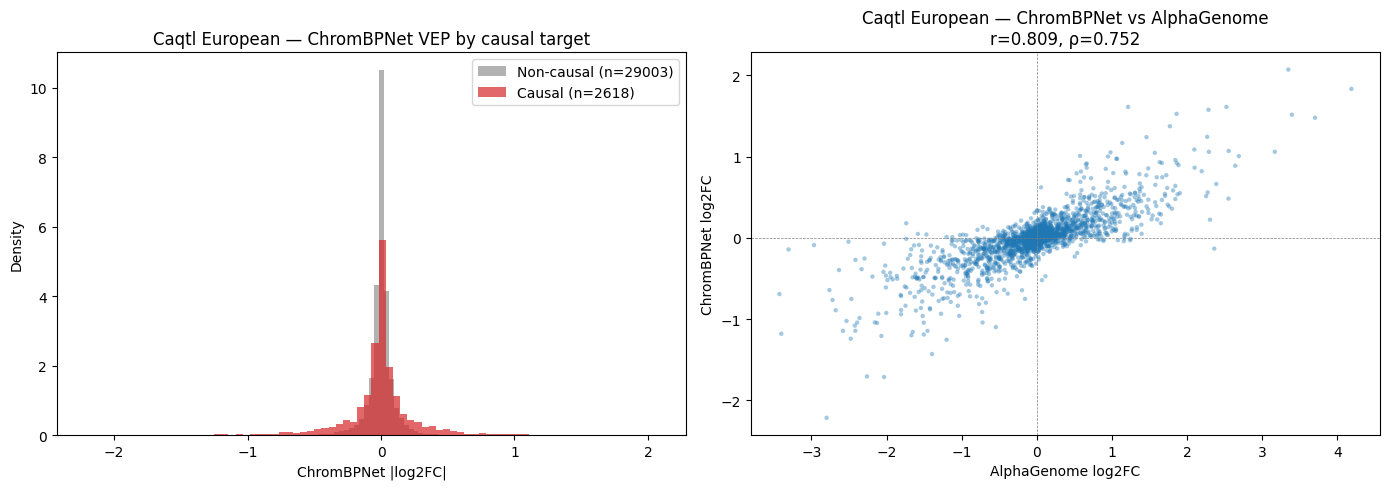


Pearson r  (ChromBPNet vs AlphaGenome): 0.8095 (p=0.00e+00)
Spearman ρ: 0.7518

Causal |log2fc| mean: 0.1581
Non-causal |log2fc| mean: 0.0552


In [12]:
from scipy.stats import pearsonr, spearmanr

pop_label = POPULATION.replace("_", " ").title()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: ChromBPNet |log2FC| distribution colored by binary causal target ---
causal = merged_causality[merged_causality['target'] == 1]['log2fc']
non_causal = merged_causality[merged_causality['target'] == 0]['log2fc']

axes[0].hist(non_causal, bins=80, alpha=0.6, color='grey',
             label=f'Non-causal (n={len(non_causal)})', density=True)
axes[0].hist(causal, bins=80, alpha=0.7, color='tab:red',
             label=f'Causal (n={len(causal)})', density=True)
axes[0].set_xlabel('ChromBPNet |log2FC|')
axes[0].set_ylabel('Density')
axes[0].set_title(f'{pop_label} — ChromBPNet VEP by causal target')
axes[0].legend()

# --- Plot 2: ChromBPNet log2FC vs AlphaGenome log2FC (coefficient subset) ---
r_pred, p_pred = pearsonr(merged_coefficient['log2fc'], merged_coefficient['prediction'])
rho_pred, _ = spearmanr(merged_coefficient['log2fc'], merged_coefficient['prediction'])

axes[1].scatter(merged_coefficient['prediction'], merged_coefficient['log2fc'],
                alpha=0.4, s=10, color='tab:blue', edgecolors='none')
axes[1].set_xlabel('AlphaGenome log2FC')
axes[1].set_ylabel('ChromBPNet log2FC')
axes[1].set_title(f'{pop_label} — ChromBPNet vs AlphaGenome\nr={r_pred:.3f}, ρ={rho_pred:.3f}')
axes[1].axhline(0, color='grey', linewidth=0.5, linestyle='--')
axes[1].axvline(0, color='grey', linewidth=0.5, linestyle='--')

plt.tight_layout()
vep_fig_path = FIG_DIR / "causality_coefficient_comparison.png"
fig.savefig(vep_fig_path, dpi=200, bbox_inches='tight')
print(f"Saved: {vep_fig_path}")
plt.show()

print(f"\nPearson r  (ChromBPNet vs AlphaGenome): {r_pred:.4f} (p={p_pred:.2e})")
print(f"Spearman ρ: {rho_pred:.4f}")
print(f"\nCausal |log2fc| mean: {causal.abs().mean():.4f}")
print(f"Non-causal |log2fc| mean: {non_causal.abs().mean():.4f}")

## 8. Save Results

In [13]:
OUT_DIR = BASE_DIR / "SEAM_ChromBPNet" / "results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Save both causality and coefficient results, tagged by population
merged_causality.to_feather(OUT_DIR / f"chrombpnet_vep_{POPULATION}_causality.feather")
merged_coefficient.to_feather(OUT_DIR / f"chrombpnet_vep_{POPULATION}_coefficient.feather")

print(f"Saved to {OUT_DIR}:")
print(f"  chrombpnet_vep_{POPULATION}_causality.feather  ({len(merged_causality)} rows)")
print(f"  chrombpnet_vep_{POPULATION}_coefficient.feather ({len(merged_coefficient)} rows)")

Saved to /grid/wsbs/home_norepl/pmantill/Human_nc_variants/SEAM_population_analysis/SEAM_ChromBPNet/results:
  chrombpnet_vep_caqtl_european_causality.feather  (31621 rows)
  chrombpnet_vep_caqtl_european_coefficient.feather (2618 rows)
